In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from windrose import WindroseAxes  #using https://pypi.org/project/windrose/
import glob
import os
from datetime import datetime, timedelta

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


Plot the temporal evolution of windroses for the whole nested domain - Figure S11

In [2]:
# Data processing for each diurnal period
paths = {
    "Default(Bulk+NoUCM)": "/g/data/fy29/mf9078/run_WRF/etamodified/output/0out/animation/",
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

time_periods = {
    "Before Sunrise": (2, 5),
    "Morning": (7, 10),
    "Peak Solar Heating": (11, 14),
    "Afternoon": (15, 18),
    "Evening": (19, 22)
}

# Dictionary to store all wind data for each scenario and time period
scenario_period_data = {}

for scenario_name in paths.keys():
    scenario_period_data[scenario_name] = {}
    for period_name in time_periods.keys():
        scenario_period_data[scenario_name][period_name] = {
            'ws': [],
            'wd': []
        }

# Function to determine time period from AEST hour
def get_time_period(hour_aest):
    for period_name, (start_hour, end_hour) in time_periods.items():
        if start_hour <= hour_aest <= end_hour:
            return period_name
    return None

for scenario_name, path in paths.items():
    print(f"\nProcessing {scenario_name}...")
    
    file_pattern = os.path.join(path, "wrfout_d02_2017-01-*")
    file_list = sorted(glob.glob(file_pattern))
    print(f"Found {len(file_list)} files for {scenario_name}")
    
    for i, file_path in enumerate(file_list):
        try:
            # Extract time from filename and convert to AEST
            timestamp_utc = datetime.strptime(os.path.basename(file_path)[11:], "%Y-%m-%d_%H:%M:%S")
            timestamp_aest = timestamp_utc + timedelta(hours=10)
            hour_aest = timestamp_aest.hour
            
            # Determine which time period this file belongs to
            period_name = get_time_period(hour_aest)
            
            if period_name is None:
                continue  # Skip files that don't fall in any defined period
            
            ds = xr.open_dataset(file_path)
            
            # Calculate wind speed and direction
            U10 = ds["U10"]
            V10 = ds["V10"]
            ws = np.sqrt(U10**2 + V10**2)
            wd = 180 + (180 / np.pi) * np.arctan2(U10, V10)

            ws_values = ws.values
            wd_values = wd.values

            # Flatten arrays to 1D (combine all spatial dimensions)
            ws_flat = ws_values.flatten()
            wd_flat = wd_values.flatten()
            
            # Remove only NaN values (if any exist)
            valid_mask = ~(np.isnan(ws_flat) | np.isnan(wd_flat))
            ws_valid = ws_flat[valid_mask]
            wd_valid = wd_flat[valid_mask]
            
            # Collect data for the appropriate time period
            scenario_period_data[scenario_name][period_name]['ws'].append(ws_valid)
            scenario_period_data[scenario_name][period_name]['wd'].append(wd_valid)
            
            ds.close()
            
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            continue

# Combine data for each scenario-period combination
for scenario_name in paths.keys():
    for period_name in time_periods.keys():
        ws_list = scenario_period_data[scenario_name][period_name]['ws']
        wd_list = scenario_period_data[scenario_name][period_name]['wd']
        
        if ws_list:
            combined_ws = np.concatenate(ws_list)
            combined_wd = np.concatenate(wd_list)
            
            scenario_period_data[scenario_name][period_name]['ws'] = combined_ws
            scenario_period_data[scenario_name][period_name]['wd'] = combined_wd
            
            print(f"{scenario_name} - {period_name}: {len(combined_ws)} data points")
        else:
            # No data for this combination
            scenario_period_data[scenario_name][period_name]['ws'] = np.array([])
            scenario_period_data[scenario_name][period_name]['wd'] = np.array([])
            print(f"{scenario_name} - {period_name}: No data points")



Processing Default(Bulk+NoUCM)...
Found 241 files for Default(Bulk+NoUCM)

Processing LCZ...
Found 241 files for LCZ

Processing WSF-MB...
Found 241 files for WSF-MB

Processing Geoscape...
Found 241 files for Geoscape
Default(Bulk+NoUCM) - Before Sunrise: 3248000 data points
Default(Bulk+NoUCM) - Morning: 3248000 data points
Default(Bulk+NoUCM) - Peak Solar Heating: 3248000 data points
Default(Bulk+NoUCM) - Afternoon: 3248000 data points
Default(Bulk+NoUCM) - Evening: 3248000 data points
LCZ - Before Sunrise: 3248000 data points
LCZ - Morning: 3248000 data points
LCZ - Peak Solar Heating: 3248000 data points
LCZ - Afternoon: 3248000 data points
LCZ - Evening: 3248000 data points
WSF-MB - Before Sunrise: 3248000 data points
WSF-MB - Morning: 3248000 data points
WSF-MB - Peak Solar Heating: 3248000 data points
WSF-MB - Afternoon: 3248000 data points
WSF-MB - Evening: 3248000 data points
Geoscape - Before Sunrise: 3248000 data points
Geoscape - Morning: 3248000 data points
Geoscape - Pe

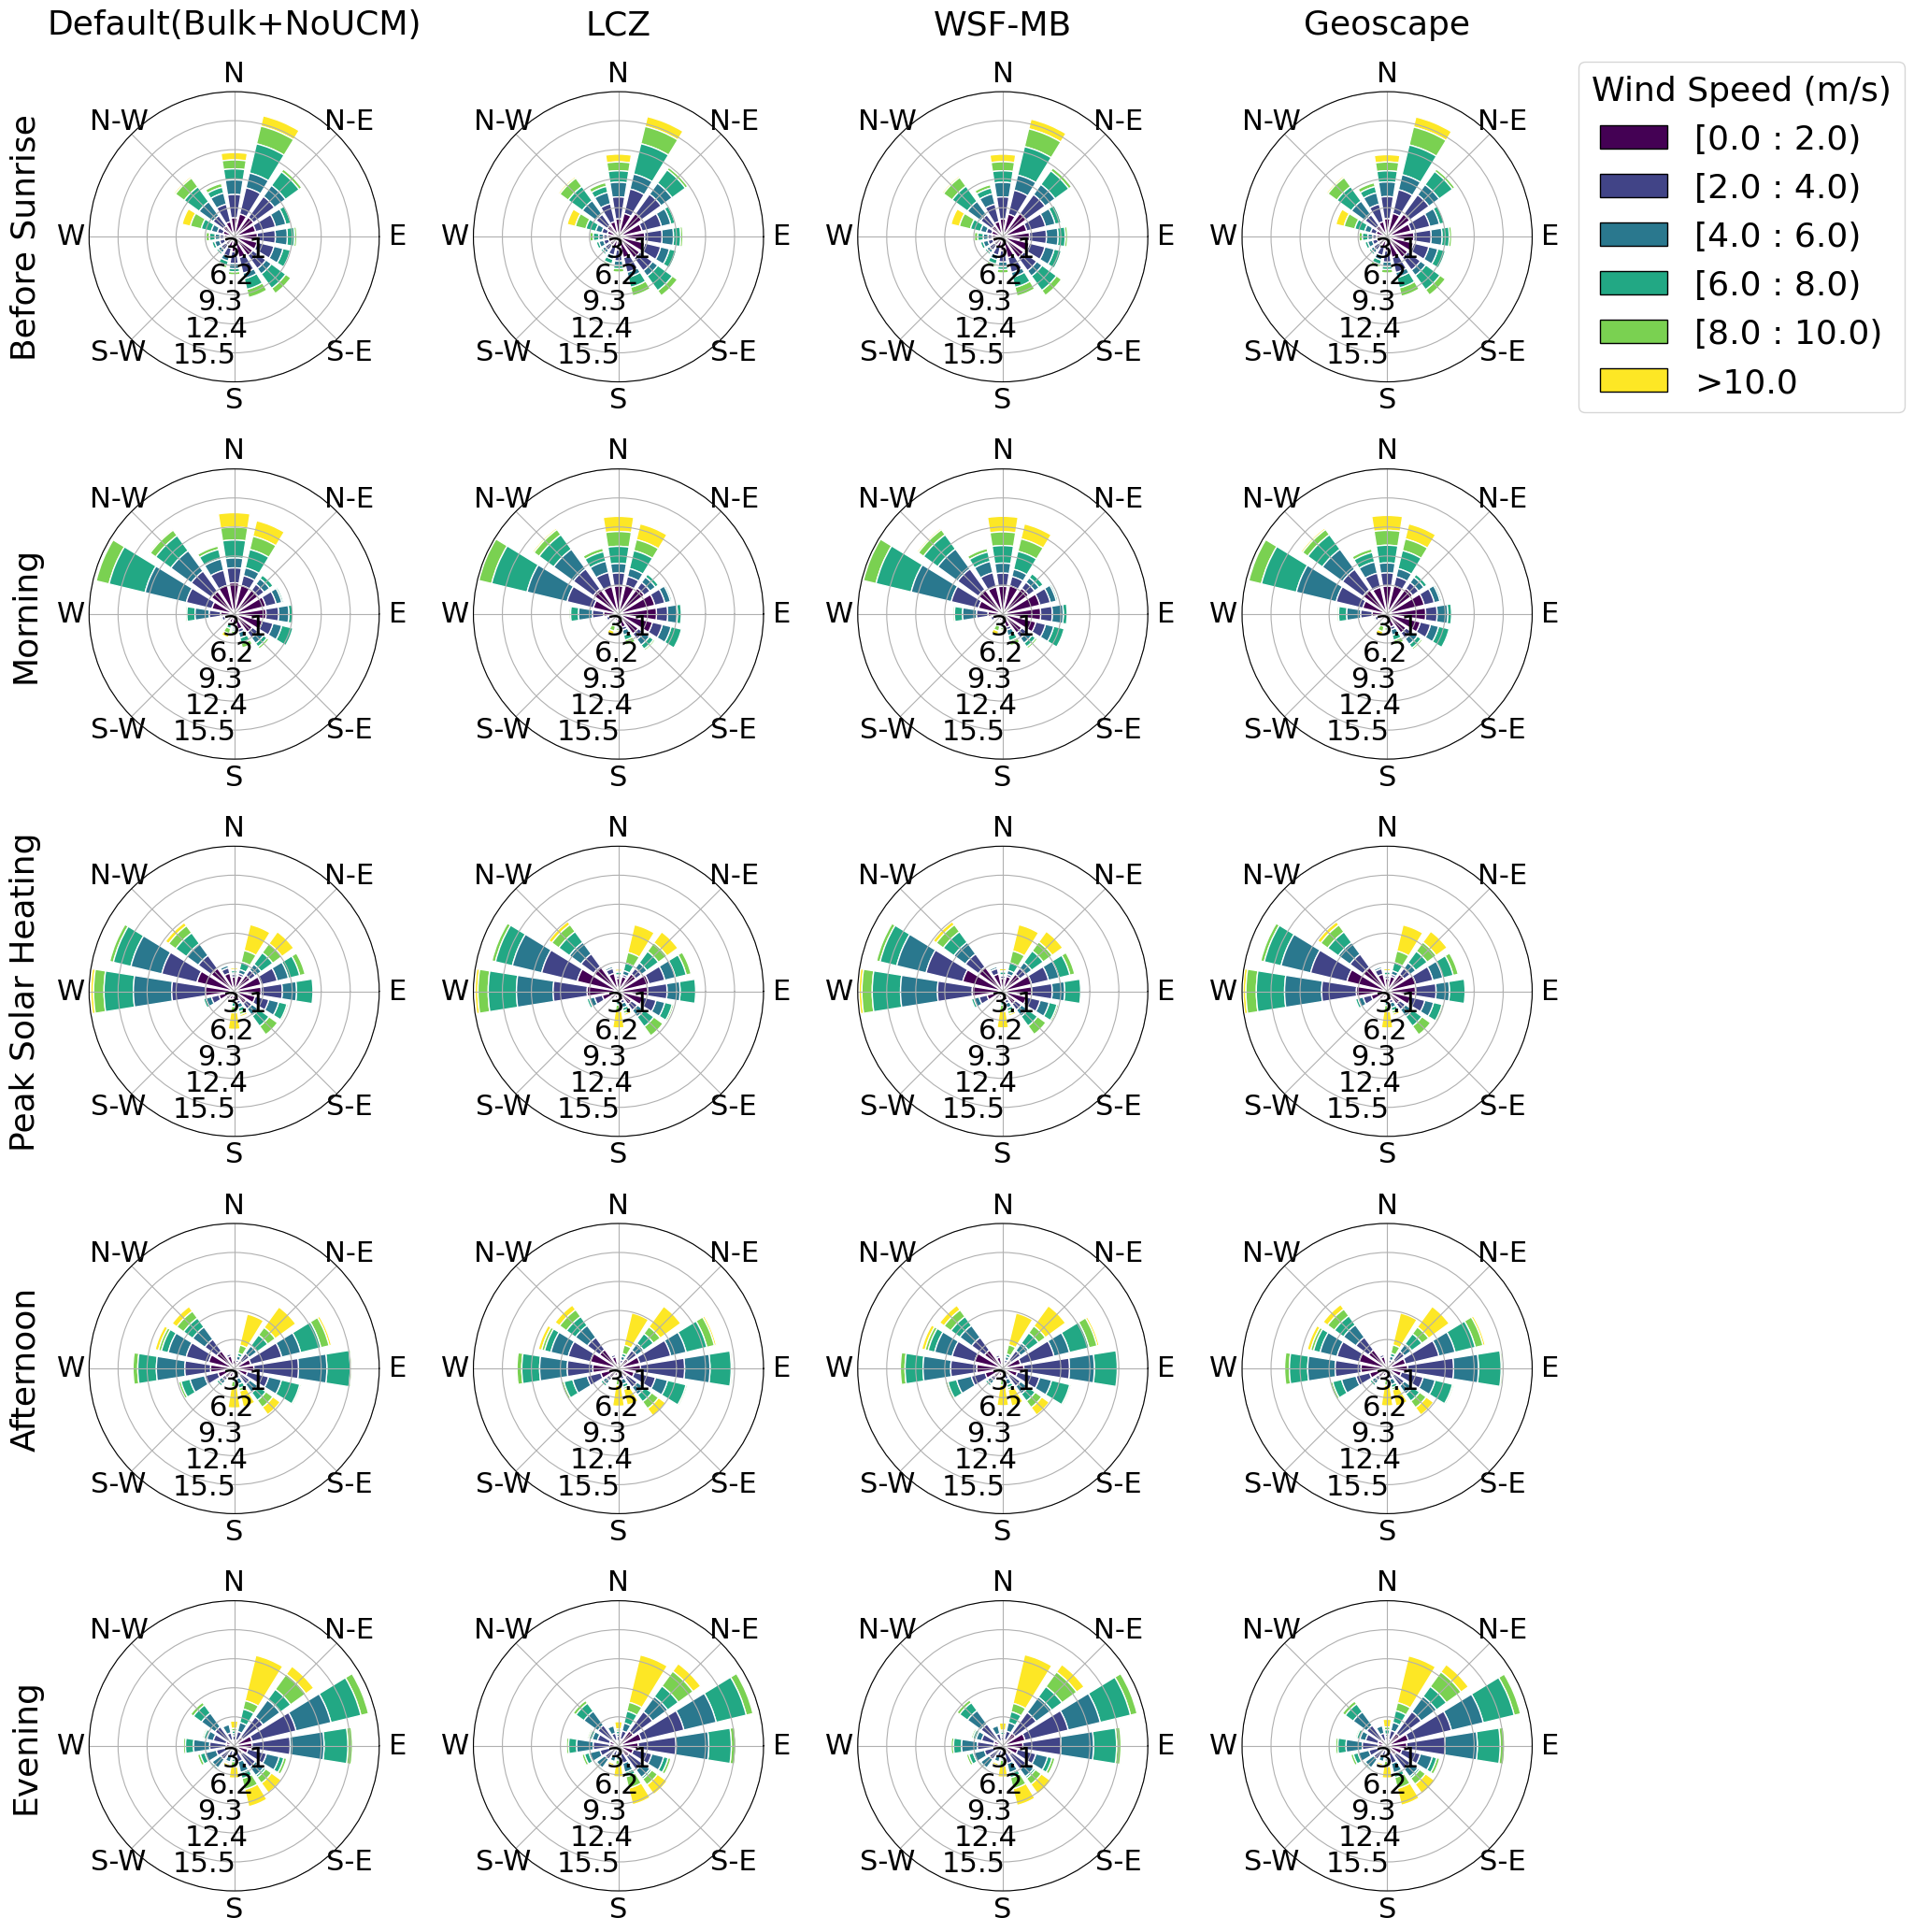


SUMMARY STATISTICS

BEFORE SUNRISE:
----------------------------------------
  Default(Bulk+NoUCM): 3,248,000 points, Mean WS:  4.16 m/s, Max WS: 16.93 m/s
  LCZ         : 3,248,000 points, Mean WS:  4.11 m/s, Max WS: 16.46 m/s
  WSF-MB      : 3,248,000 points, Mean WS:  4.12 m/s, Max WS: 16.80 m/s
  Geoscape    : 3,248,000 points, Mean WS:  4.12 m/s, Max WS: 17.38 m/s

MORNING:
----------------------------------------
  Default(Bulk+NoUCM): 3,248,000 points, Mean WS:  3.87 m/s, Max WS: 16.22 m/s
  LCZ         : 3,248,000 points, Mean WS:  3.82 m/s, Max WS: 15.99 m/s
  WSF-MB      : 3,248,000 points, Mean WS:  3.84 m/s, Max WS: 16.12 m/s
  Geoscape    : 3,248,000 points, Mean WS:  3.83 m/s, Max WS: 16.23 m/s

PEAK SOLAR HEATING:
----------------------------------------
  Default(Bulk+NoUCM): 3,248,000 points, Mean WS:  4.39 m/s, Max WS: 31.01 m/s
  LCZ         : 3,248,000 points, Mean WS:  4.32 m/s, Max WS: 27.05 m/s
  WSF-MB      : 3,248,000 points, Mean WS:  4.33 m/s, Max WS: 29.67 

In [ ]:
# Create the windrose plots (5 rows x 4 columns)

fig = plt.figure(figsize=(20, 25))
scenario_order = ["Default(Bulk+NoUCM)", "LCZ", "WSF-MB", "Geoscape"]
period_order = ["Before Sunrise", "Morning", "Peak Solar Heating", "Afternoon", "Evening"]
subplot_counter = 1

for row, period_name in enumerate(period_order):
    for col, scenario_name in enumerate(scenario_order):
        # Create subplot with windrose projection
        ax = fig.add_subplot(5, 4, subplot_counter, projection="windrose")
        
        ws_data = scenario_period_data[scenario_name][period_name]['ws']
        wd_data = scenario_period_data[scenario_name][period_name]['wd']
        
        if len(ws_data) > 0:
            # Create windrose plot
            ax.bar(wd_data, ws_data, normed=True, opening=0.8, edgecolor="white", bins=(0, 2, 4, 6, 8, 10))
            
            # Set fixed radial ticks
            ax.set_yticks([3.1, 6.2, 9.3, 12.4, 15.5])
            ax.set_yticklabels(['3.1', '6.2', '9.3', '12.4', '15.5'])
            
            # Set font sizes for windrose elements
            ax.tick_params(axis='both', labelsize=22)  # For percentage labels
            
            # Set font size for direction labels (N, NE, E, etc.)
            for label in ax.get_xticklabels():
                label.set_fontsize(22)
                
            # Set font size for radial (percentage) labels  
            for label in ax.get_yticklabels():
                label.set_fontsize(22)

            # Move radial labels to the left (West = 245 degrees)
            ax.set_rlabel_position(245)
                
        else:
            # No data available - create empty plot with text
            ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=26)  #, fontweight='bold'
        
        # Set title for first row (scenarios)
        if row == 0:
            ax.set_title(scenario_name, fontsize=26, pad=20)  #, fontweight='bold'
        
        # Set ylabel for first column (time periods)
        if col == 0:
            ax.text(-0.22, 0.5, period_name, transform=ax.transAxes, 
                   rotation=90, ha='center', va='center', 
                   fontsize=26) #, fontweight='bold'
        
        # Add legend only for the top-right subplot
        if row == 0 and col == len(scenario_order) - 1:
            ax.legend(title='Wind Speed (m/s)', loc='center left', bbox_to_anchor=(1.1, 0.5), 
                     fontsize=26, title_fontsize=26)
        
        subplot_counter += 1

# Create a dummy windrose to get legend handles
dummy_ax = fig.add_subplot(111, projection="windrose", frame_on=False)
dummy_ax.bar([0, 90, 180, 270], [1, 2, 3, 4], normed=True, opening=0.8, edgecolor="white")
handles, labels = dummy_ax.get_legend_handles_labels()
dummy_ax.remove()  # Remove the dummy subplot

plt.subplots_adjust(hspace=0.3, wspace=0.3) 
plt.savefig('windrose_scenarios_timeperiods.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
for period_name in period_order:
    print(f"\n{period_name.upper()}:")
    print("-" * 40)
    for scenario_name in scenario_order:
        ws_data = scenario_period_data[scenario_name][period_name]['ws']
        if len(ws_data) > 0:
            print(f"  {scenario_name:12}: {len(ws_data):6,} points, "
                  f"Mean WS: {np.mean(ws_data):5.2f} m/s, "
                  f"Max WS: {np.max(ws_data):5.2f} m/s")
        else:
            print(f"  {scenario_name:12}: No data points")